# Exploration

## Variable cible

In [9]:
import pandas as pd

In [10]:
y = pd.read_csv('../../Dataset/Y_train.csv',index_col=0)
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prdtypecode  84916 non-null  int64
dtypes: int64(1)
memory usage: 1.3 MB


In [11]:
if not y.index.is_unique:
    print("Warning: Duplicate indices found!")

In [12]:
y2 = pd.read_csv('../../Dataset/Y_train.csv')
pd.Series(y.index == y2.index).unique(), y2.index
# L'index de y venant de index_col=0 est normal, donc pas de précaution particulière à prendre à ce sujet.

(array([ True]), RangeIndex(start=0, stop=84916, step=1))

In [13]:
del y2

In [14]:
y.head(15)

,prdtypecode
0,10
1,2280
2,50
3,1280
4,2705
5,2280
6,10
7,2522
8,1280
9,2582


In [15]:
y.prdtypecode.nunique()

27

In [16]:
y.prdtypecode.unique()

array([  10, 2280,   50, 1280, 2705, 2522, 2582, 1560, 1281, 1920, 2403,
       1140, 2583, 1180, 1300, 2462, 1160, 2060,   40,   60, 1320, 1302,
       2220, 2905, 2585, 1940, 1301])

Le graphique de Jessy montre en fait tous les codes produits, pas une liste abrégée ! Le préciser dans le rendu.

In [17]:
y.describe()

,prdtypecode
count,84916.000000
mean,1773.219900
std,788.179885
min,10.000000
25%,1281.000000
50%,1920.000000
75%,2522.000000
max,2905.000000


In [18]:
y.value_counts()

prdtypecode
2583           10209
1560            5073
1300            5045
2060            4993
2522            4989
1280            4870
2403            4774
2280            4760
1920            4303
1160            3953
1320            3241
10              3116
2705            2761
1140            2671
2582            2589
40              2508
2585            2496
1302            2491
1281            2070
50              1681
2462            1421
2905             872
60               832
2220             824
1301             807
1940             803
1180             764
Name: count, dtype: int64

In [19]:
v=y.value_counts(normalize=True).tolist()
v

[0.12022469263742994,
 0.05974139149276932,
 0.05941165386970653,
 0.058799283998304204,
 0.05875217862358095,
 0.057350793725564085,
 0.05622026473220595,
 0.05605539592067455,
 0.05067360685854256,
 0.04655188657025767,
 0.03816712986951811,
 0.03669508690941636,
 0.0325144849027274,
 0.031454613971454146,
 0.030488953789627397,
 0.029535069951481464,
 0.029393753827311696,
 0.029334872108907627,
 0.02437703141928494,
 0.0197960337274483,
 0.016734184370436667,
 0.010268971689669792,
 0.009797917942437232,
 0.00970370719299072,
 0.009503509350416883,
 0.009456403975693627,
 0.008997126572141882]

In [20]:
import numpy as np
ratios = [v[k]/v[-1] for k in range(len(v))]
max(ratios),np.median(ratios),np.std(ratios) #,np.mean(ratios)-np.std(ratios),np.mean(ratios)+np.std(ratios)

(13.362565445026178,
 np.float64(3.4960732984293195),
 np.float64(2.7014821668350457))

Comme l'indique le graphique de Jessy, les catégories sont déséquilibrées : la plupart des catégories sont 3 à 13 fois plus représentées que la plus rare. Les rééquilibrer pourrait améliorer la performance.

## Variables d'entrée

In [21]:
X = pd.read_csv('../../Dataset/X_train.csv',index_col=0)
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 3.2+ MB


In [22]:
if not X.index.is_unique:
    print("Warning: Duplicate indices found!")

In [23]:
X2 = pd.read_csv('../../Dataset/X_train.csv')
pd.Series(X.index == X2.index).unique(), X2.index
# L'index de X venant de index_col=0 est normal, donc pas de précaution particulière à prendre à ce sujet.

(array([ True]), RangeIndex(start=0, stop=84916, step=1))

In [24]:
del X2

In [25]:
X.iloc[:,0].apply(type).unique()

array([<class 'str'>], dtype=object)

In [26]:
X.iloc[:,1].dropna().apply(type).unique()

array([<class 'str'>], dtype=object)

In [27]:
X.head(30)

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786
5,Afrique Contemporaine N° 212 Hiver 2004 - Doss...,NaN,5862738,393356830
6,Christof E: Bildungsprozessen Auf Der Spur,NaN,91920807,907794536
7,Conquérant Sept Cahier Couverture Polypro 240 ...,CONQUERANT CLASSIQUE Cahier 240 x 320 mm seyès...,344240059,999581347
8,Puzzle Scooby-Doo Avec Poster 2x35 Pieces,NaN,4239126071,1325918866
9,Tente Pliante V3s5-Pro Pvc Blanc - 3 X 4m50 - ...,Tente pliante V3S5 Pro PVC 500 gr/m² - 3 x 4m5...,3793572222,1245644185


Les variables imageid et productid semblent inutiles pour la prédiction, et servir juste à associer l'image correspondante lors du preprocessing. Il y a donc essentiellement 3 variables a priori : designation, description, image. Ce petit nombre de variables est une difficulté. En revanche, ces variables semblent avoir un contenu riche et complexe, ce qui offre un potentiel fort si on parvient à les exploiter.

In [28]:
# L'ID est sans doublon, pas de problème.
X.productid.nunique()

84916

In [29]:
# L'ID est sans doublon, pas de problème.
X.imageid.nunique()

84916

### Join

In [30]:
# Join on indexes, according to the documentation of the dataset.
df = X.join(y)
df

,designation,description,productid,imageid,prdtypecode
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705
...,...,...,...,...,...
84911,The Sims [ Import Anglais ],NaN,206719094,941495734,40
84912,Kit piscine acier NEVADA déco pierre Ø 3.50m x...,<b>Description complète :</b><br />Kit piscine...,3065095706,1188462883,2583
84913,Journal Officiel De La Republique Francaise N°...,NaN,440707564,1009325617,2280
84914,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403,1560


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
 4   prdtypecode  84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.9+ MB


### Variables textuelles

Les textes sont en au moins 3 langues (allemand, français, anglais), ce qui peut compliquer le NLP. Rakuten étant une entreprise mondiale, on peut s'attendre à ce que bien plus que 3 langues soient représentées dans le jeu de données. Mais le français semble majoritaire.

In [32]:
print('\n#\n'.join(X.designation.iloc[:100]))

Olivia: Personalisiertes Notizbuch / 150 Seiten / Punktraster / Ca Din A5 / Rosen-Design
#
Journal Des Arts (Le) N° 133 Du 28/09/2001 - L'art Et Son Marche Salon D'art Asiatique A Paris - Jacques Barrere - Francois Perrier - La Reforme Des Ventes Aux Encheres Publiques - Le Sna Fete Ses Cent Ans.
#
Grand Stylet Ergonomique Bleu Gamepad Nintendo Wii U - Speedlink Pilot Style
#
Peluche Donald - Europe - Disneyland 2000 (Marionnette À Doigt)
#
La Guerre Des Tuques
#
Afrique Contemporaine N° 212 Hiver 2004 - Dossier Japon / Afrique
#
Christof E: Bildungsprozessen Auf Der Spur
#
Conquérant Sept Cahier Couverture Polypro 240 X 320 Mm 96 Pages 90g Seyès Incolore
#
Puzzle Scooby-Doo Avec Poster 2x35 Pieces
#
Tente Pliante V3s5-Pro Pvc Blanc - 3 X 4m50 - Longueur : 4m50 Largeur : 3 M Blanc H
#
Eames Inspired Sxw Chair - Pink - Black
#
Fauteuil Chesterfield Brenton 100% Cuir De Buffle - Vert Empire
#
Peaceable Kingdom Wheres Bear? The Hide And Find Stacking Block Game For 2 Year Olds
#
Paire De 

Beaucoup d'éléments dans les désignations ne sont pas des mots mais peuvent être quand même pertinents pour la prédiction. Nettoyer les désignations sans nuire à la qualité des prédictions peut être délicat. De nombreuses désignations semblent confuses, difficiles à catégoriser même par un humain.

In [33]:
print('\n#\n'.join(X.dropna().description.iloc[:15]))

PILOT STYLE Touch Pen de marque Speedlink est 1 stylet ergonomique pour GamePad Nintendo Wii U.<br> Pour un confort optimal et une précision maximale sur le GamePad de la Wii U: ce grand stylet hautement ergonomique est non seulement parfaitement adapté à votre main mais aussi très élégant.<br> Il est livré avec un support qui se fixe sans adhésif à l'arrière du GamePad<br> <br> Caractéristiques:<br> Modèle: Speedlink PILOT STYLE Touch Pen<br> Couleur: Bleu<br> Ref. Fabricant: SL-3468-BE<br> Compatibilité: GamePad Nintendo Wii U<br> Forme particulièrement ergonomique excellente tenue en main<br> Pointe à revêtement longue durée conçue pour ne pas abîmer l'écran tactile<br> En bonus : Support inclu pour GamePad<br> <span class="vga_style2"><b></b><br>
#
Luc a des id&eacute;es de grandeur. Il veut organiser un jeu de guerre de boules de neige et s'arranger pour en &ecirc;tre le vainqueur incontest&eacute;. Mais Sophie s'en m&ecirc;le et chambarde tous ses plans...
#
CONQUERANT CLASSIQUE 

Les descriptions aussi sont confuses et parsemées de parasites variés. Leurs tailles sont très variables. L'absence de description pour 35% des données représente aussi une difficulté.

In [34]:
df['len_designation']=X.designation.apply(len)

In [35]:
# Les descriptions non NA sont toutes différentes de la chaîne vide '', donc on n'introduit pas d'ambiguïté avec fillna('').
df['len_description']=X.description.fillna('').apply(len)

In [36]:
#TODO? histogram
# Designation lengths (character counts)
df['len_designation'].describe()

count    84916.000000
mean        70.163303
std         36.793383
min         11.000000
25%         43.000000
50%         64.000000
75%         90.000000
max        250.000000
Name: len_designation, dtype: float64

In [37]:
#TODO? histogram
# description lengths (character counts) (*except* for missing descriptions)
X.description.dropna().apply(len).describe()

count    55116.000000
mean       808.171692
std        805.462153
min          1.000000
25%        259.000000
50%        626.000000
75%       1034.000000
max      12451.000000
Name: description, dtype: float64

In [38]:
#TODO? histogram
# description lengths (character counts) (*including* missing descriptions)
df['len_description'].describe()

count    84916.000000
mean       524.555926
std        754.893905
min          0.000000
25%          0.000000
50%        231.000000
75%        823.000000
max      12451.000000
Name: len_description, dtype: float64

In [39]:
#TODO? values and plot: moyenne de la longueur de la description par type de produit

70 descriptions font moins de 5 caractères et semblent presque toutes inutiles à la prédiction. Heureusement, elles ne représentent que 0,1% du jeu de données.

In [40]:
# Taille, Nombre de descriptions de cette taille
v=X.description.dropna().apply(len)[X.description.dropna().apply(len) <= 5].value_counts().sort_index()
v

description
1    28
2     9
3    14
4    19
5     7
Name: count, dtype: int64

In [41]:
# Descriptions de moins de 5 caractères
X.description.dropna()[X.description.dropna().apply(len) <= 5].unique()

array(['50PV.', '1989', '...', 'promo', '-', '0', '1985', '1984', 'nc',
       '.', 'Batty', '(1', 'p', 'jeu', '1972.', '&gt;', '1980', 'Buste',
       'Noir', '1969', 'aa', 'Gris', 'B1962', '3323', '1988', '1947',
       '1986', '1991', '1992', '--', '1996', 'table'], dtype=object)

In [42]:
# Nombre et pourcentage de ces descriptions
v.sum(),v.sum()/X.description.dropna().shape[0]

(np.int64(77), np.float64(0.0013970534871906525))

À partir de 6 caractères, les descriptions commencent à sembler utiles à la prédiction : par exemple, "Roman", "Chevet", "Proust".

In [43]:
# Descriptions de 6 caractères
X.description.dropna()[X.description.dropna().apply(len) == 6].unique()

array(['<br />', 'doudou', 'Notice', 'Roman.', 'argent', 'F.215.',
       'Proust', 'Marron', '18X7cm', 'Chevet'], dtype=object)

In [44]:
# Descriptions de 7 caractères
X.description.dropna()[X.description.dropna().apply(len) == 7].unique()

array(['Piano -', '34x29cm', '2259.00', 'Mensuel', '...<br>', 'Commode',
       'RoHS CE', 'Poupon '], dtype=object)

#### Mots les plus fréquents

##### Variable : description

In [45]:
text = ' '.join(X.description.dropna().str.lower())
text[:100]

'pilot style touch pen de marque speedlink est 1 stylet ergonomique pour gamepad nintendo wii u.<br> '

Text(0.5, 1.0, 'Mots les plus fréquents : du numéro 1 au numéro 15')

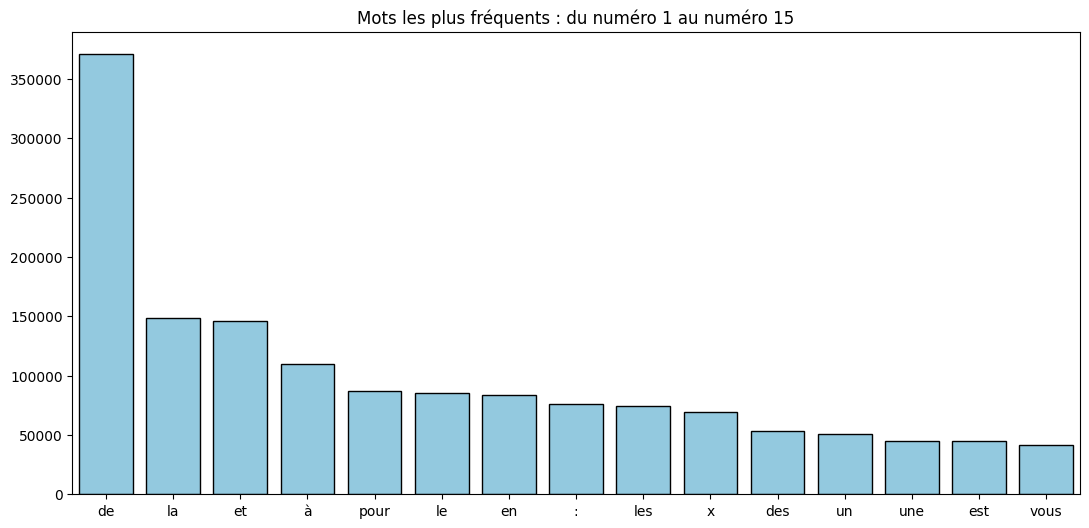

In [46]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

dico = Counter(text.split())
first=0
amount=15
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
freq = [m[1] for m in dico.most_common(first+amount)[first:]]

plt.figure(figsize= (13,6))
sns.barplot(x=mots, y=freq, color='skyblue', edgecolor='black')
plt.title(f'Mots les plus fréquents : du numéro {first+1} au numéro {first+amount}')

In [47]:
first=0
amount=50
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'de | la | et | à | pour | le | en | : | les | x | des | un | une | est | vous | avec | du | - | /> | votre | 1 | / | <br | dans | ou | sur | pas | cm | plus | peut | il | que | au | ne | haute | par | couleur | a | piscine | être | 2 | * | ce | sont | qualité | qui | the | tout | facile | taille'

In [48]:
# Initialiser la variable des mots vides
stop_words = set('p br li ul cm mm X A b H div'.split())
stop_words |= set(mots)
print(stop_words)

{'en', 'peut', 'A', 'the', 'votre', 'tout', 'est', 'facile', '*', 'que', 'un', 'mm', '/', 'être', 'sont', 'pas', '/>', 'piscine', 'avec', 'pour', 'x', 'qui', 'taille', 'du', 'par', '1', 'de', '-', 'ne', 'haute', 'ul', 'une', 'vous', 'et', 'des', 'qualité', 'couleur', 'b', 'ce', 'le', 'cm', 'br', 'les', 'la', 'X', 'au', 'sur', 'dans', 'li', 'plus', 'il', 'H', ':', 'à', 'ou', '2', 'a', 'div', 'p', '<br'}


In [49]:
first=50
amount=300
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'and | /><br | taille: | sans | 3 | plaît | matériel: | dimensions | aux | se | comme | 4 | vos | s&#39;il | enfants | 100% | acier | très | bois | &#43; | l&#39;eau | lumière | cette | to | raison | son | produit | />- | neuf | of | décoration | forfait | non | caractéristiques: | temps | jeu | taie | protection | mode | couleur: | d&#39;un | mesure | batterie | d&#39;une | pouvez | type | main | coussin | (l | 6 | mm | tous | 5 | filtration | l | sac | led | &amp; | sa | bébé | comprend: | contenu | avant | d&#39;eau | design | utiliser | for | pompe | maison | ans | plastique | 1x | hauteur | permettre | couleurs | différence | si | 10 | marque | 1pc | nous | fait | rc | paquet | parfait | elle | surface | durable | ! | blanc | ? | poids | //// | style | m? | forme | d&#39;oreiller | peuvent | cadeau | grande | :</strong> | ces | tissu | couverture | permet | sécurité | également | structure | faire | grand | grâce | facilement | longueur | 8 | voiture | utilisé | </p> | système | m

##### Variable : designation

In [50]:
text = ' '.join(X.designation.str.lower())
text[:100]

'olivia: personalisiertes notizbuch / 150 seiten / punktraster / ca din a5 / rosen-design journal des'

Text(0.5, 1.0, 'Mots les plus fréquents : du numéro 1 au numéro 15')

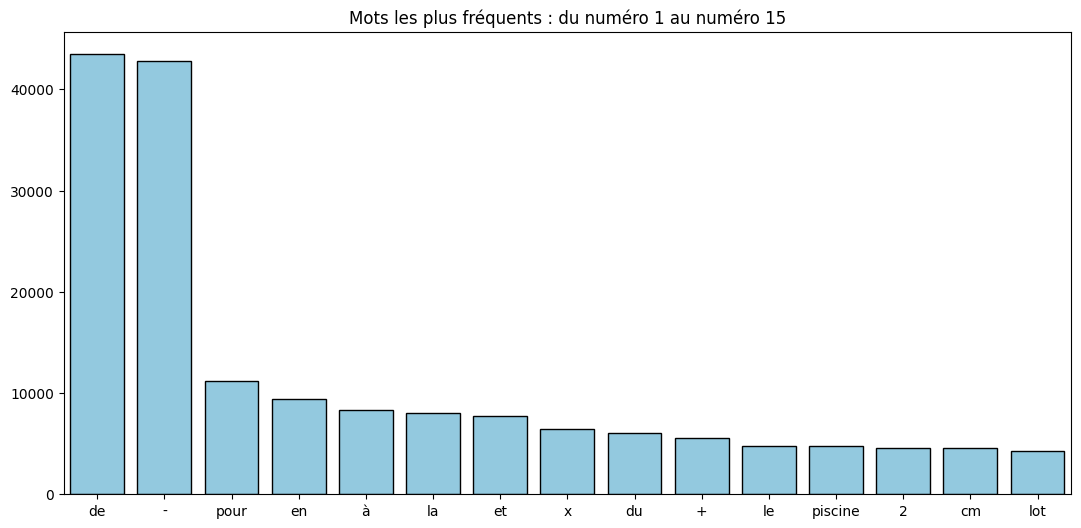

In [51]:
from collections import Counter
import seaborn as sns

dico = Counter(text.split())
first=0
amount=15
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
freq = [m[1] for m in dico.most_common(first+amount)[first:]]

plt.figure(figsize= (13,6))
sns.barplot(x=mots, y=freq, color='skyblue', edgecolor='black')
plt.title(f'Mots les plus fréquents : du numéro {first+1} au numéro {first+amount}')

In [52]:
first=0
amount=50
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'de | - | pour | en | à | la | et | x | du | + | le | piscine | 2 | cm | lot | n° | les | jeu | avec | coussin | : | des | 3 | / | 1 | m | kit | 4 | rc | taie | enfants | blanc | a | bois | led | the | décor | noël | home | & | bébé | décoration | sac | noir | jeux | bâche | bleu | drone | 5 | par'

In [53]:
first=50
amount=300
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'of | carte | mini | 6 | couverture | journal | portable | d\'oreiller | dji | acier | jouet | sur | console | mm | lampe | au | cadeau | magideal | voiture | cuisine | 10 | jardin | set | jouets | gris | spa | table | canapé | figurine | housse | pompe | carnet | coton | tapis | toy | classique | bulles | bricolage | tissu | for | support | case | ronde | rouge | maison | douche | téléchargement | 8 | peinture | vert | protection | cover | notes | intex | collection | un | 3d | 12 | super | rose | filtre | livres | quadcopter | peluche | 7 | bain | couleur | salle | bloc-notes | l | lit | stream | gonflable | oreiller | car | sans | pièces | modèle | nintendo | cahier | lumière | solaire | enfant | matelas | sofa | pro | bureau | métal | taille | edition | accueil | france | caméra | throw | papier | plastique | and | silicone | poche | rangement | 20 | pouces | pvc | accessoires | double | mode | fpv | places | tome | (le) | batterie | mavic | star | decor | magic | chaise | | | dans

#### Wordclouds

##### Initialisation

In [54]:
# Complète l'installation de nltk. Utile seulement une fois par PC.
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/val/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [55]:
from nltk.corpus import stopwords

stop_words |= set(stopwords.words('french'))
print(stop_words)

{'en', 'peut', 'seriez', 'avions', 'm', 'étions', 'est', 'facile', 'ayante', 'eue', 'que', 'avais', 'aux', 'nous', '/', 'aurai', '/>', 'piscine', 'êtes', 'aurait', 'étés', 'pour', 'qui', 'auraient', 'es', 'eussions', 'l', 'une', 'vous', 'fus', 'me', 'ce', 'aurons', 'aient', 'le', 'serez', 'été', 'les', 'mais', 'la', 'X', 'ses', 'fusse', 'eûtes', 'aies', 'avez', 'ayantes', 'il', 'eut', 'avait', 'ai', 'étiez', ':', 'à', 'on', 'eusses', 'sera', 'sur', 'p', 'étantes', 'ton', 'd', 'suis', 'soyez', '*', 'était', 'eussiez', 'mm', 'ont', 'être', 'même', 'aurais', 'ces', 'x', 'ayants', '1', '-', 'ne', 'n', 'haute', 'ul', 'seras', 'eux', 'et', 'serais', 'auras', 'ils', 'eus', 'lui', 'br', 'soyons', 'eusse', 'dans', 'furent', 'te', 'aurez', '2', 'A', 'votre', 'tout', 'se', 'serai', 'eu', 'aie', 'étaient', 'un', 'notre', 'je', 'sont', 'seraient', 'taille', 'vos', 'du', 's', 'étante', 'étais', 'seront', 'eussent', 'de', 'aurions', 'serait', 'fût', 'serons', 'étée', 'couleur', 'b', 'soit', 'mes', 't

In [56]:
# Mieux sans masque
mask_coloring = None

In [57]:
# from PIL import Image
# path = 'images/mask.png'
# mask_coloring = np.array(Image.open(str(path)))

##### Variable : designation

In [58]:
import wordcloud
from wordcloud import WordCloud
wc1 = WordCloud(width=800, height=400, background_color="black", color_func = wordcloud.get_single_color_func('green'), mask = mask_coloring, max_words=100, max_font_size=50, stopwords=stop_words, random_state=42)

In [59]:
text = ' '.join(X.designation)
wc1.generate(text)
len(text)

6042902

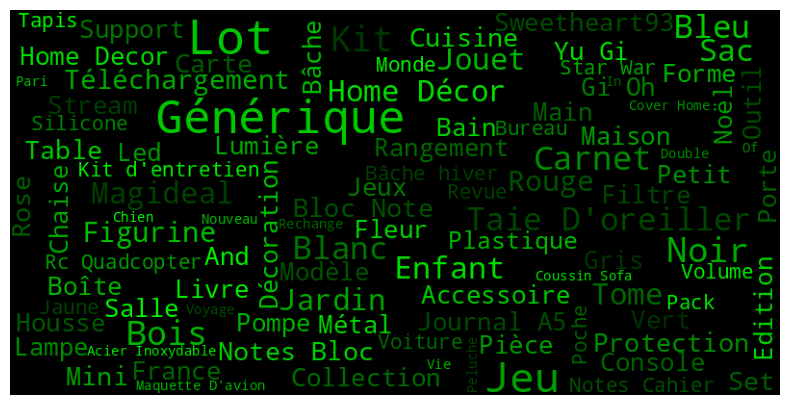

In [60]:
import matplotlib.pyplot as plt

# Générer et afficher le nuage de mots

plt.figure(figsize=(13,5))
plt.imshow(wc1)
plt.axis('off')
plt.show()

Le français semble largement majoritaire, suivi par l'anglais.

##### Variable : description

(Cellules commentées car elles mettent du temps à charger.)

In [61]:
# wc = WordCloud(width=800, height=400, background_color="black", color_func = wordcloud.get_single_color_func('green'), mask = mask_coloring, max_words=100, max_font_size=50, stopwords=stop_words, random_state=42)

In [62]:
# text = ' '.join(X.description.dropna())
# len(text)

In [63]:
# # Dure 12s.
# wc.generate(text)

In [64]:
# plt.figure(figsize=(13,5))
# plt.imshow(wc)
# plt.axis('off')
# plt.show()

### Images

#### Load

In [65]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

def load_image(row, color=True, folder = '../../Dataset/images/image_train'):
    filename = f"image_{row.imageid}_product_{row.productid}.jpg"
    path = Path(folder) / filename
    if color:
        color_arg = cv2.IMREAD_COLOR
    else:
        color_arg = cv2.IMREAD_GRAYSCALE
    img_color = cv2.imread(str(path), color_arg)
    if img_color is None:
        raise ValueError
    return img_color

#### Display

In [66]:
def display_images(rows,nrow,ncol,axis=False):
    n = len(rows)
    if n > nrow*ncol:
        print('(`rows` is too long for this grid. Not showing all values.)')
        n = nrow*ncol
    plt.figure(figsize=(13,8))
    for k in range(n):
        plt.subplot(nrow,ncol,k+1)
        row = rows.iloc[k]
        plt.imshow(load_image(row))
        if not axis:
            plt.axis('off')

Show random images from the dataset.

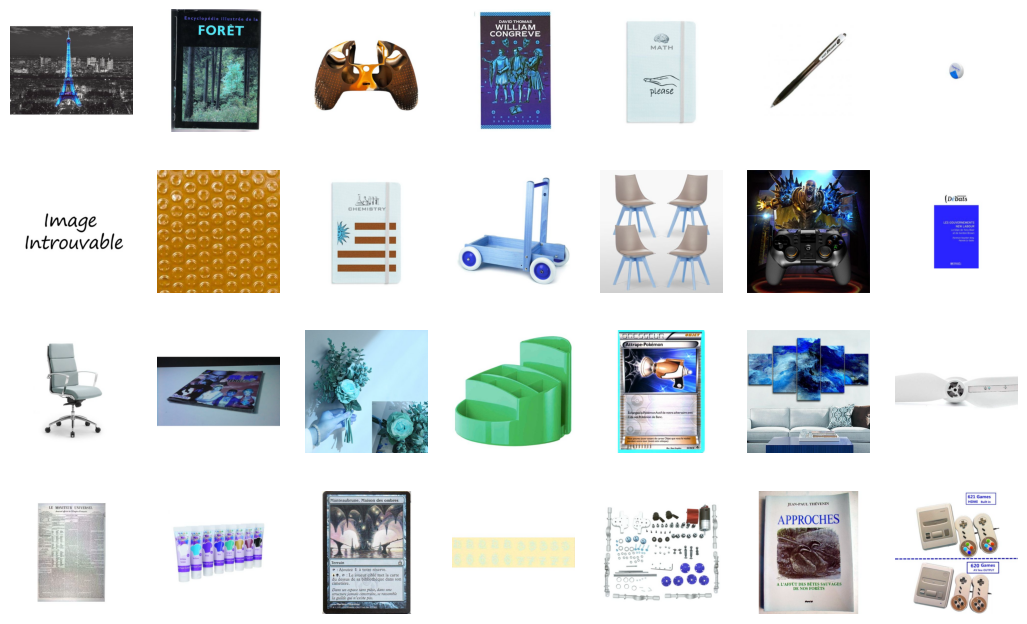

In [67]:
nrow = 4
ncol = 7
n = nrow*ncol
rows = X.sample(n)
display_images(rows,nrow,ncol)

Bien que les images aient le même nombre de pixels, certaines sur fond blanc ont des couleurs sur seulement une petite partie de l'image. On pourrait envisager de compter le nombre de pixels non blancs.

#### Pixel count

In [68]:
def count_pixels(row, product=True, folder = '../../Dataset/images/image_train'):
    img_color = load_image(row, folder = folder)
    if product:
        result = np.prod(img_color.shape)
    else:
        result = img_color.shape
    return result

On regarde les dimensions d'images aléatoires du jeu de données. (Regarder toutes les images met longtemps à charger.) Elles ont toutes les mêmes dimensions.

In [69]:
X.sample(100).apply(count_pixels,axis=1,args=(False,)).unique()

array([(500, 500, 3)], dtype=object)

In [70]:
X.sample(100).apply(count_pixels,axis=1,args=(True,)).unique()

array([750000])

In [71]:
# # Regarde pour toutes les lignes, donc met 2m30 à charger. Résultat : array([(500, 500, 3)], dtype=object).
# X.apply(count_pixels,axis=1,args=(False,)).unique()

#### Various image features

In [72]:
def get_content_bounding_box(row, threshold=254, folder = '../../Dataset/images/image_train'):
    # Load image, ensure it's grayscale for finding coordinates
    img = load_image(row, color=False, folder = folder)

    # Find all non-white pixels. A threshold of 254 handles JPEG artifacts.
    # (Pure white is 255, but compression can create values like 254)
    mask = img < threshold

    # Le compte de pixels est la somme des pixels 'True' (ou 1) dans le masque.
    essential_pixel_count = np.sum(mask)

    non_white_pixels = np.argwhere(mask)  # Returns (row, col) coordinates

    if non_white_pixels.size == 0:
        return 0, 0, 0, 0, 0  # White image

    # np.argwhere gives (row, col) which corresponds to (y, x)
    y_coords = non_white_pixels[:, 0]
    x_coords = non_white_pixels[:, 1]

    y_min, y_max = y_coords.min(), y_coords.max()
    x_min, x_max = x_coords.min(), x_coords.max()

    return essential_pixel_count, x_min, y_min, x_max, y_max

In [73]:
# # Dure 4mn10.
# coords = df.apply(get_content_bounding_box,axis=1)

In [ ]:
# coords[:4]

0    (26888, 176, 144, 319, 351)
1    (47559, 160, 112, 343, 383)
2      (16531, 72, 64, 425, 431)
3     (128374, 80, 56, 415, 447)
dtype: object

In [ ]:
# col_names = ['essential_pixel_count', 'x_min', 'y_min', 'x_max', 'y_max']
# coords_df = pd.DataFrame(coords.tolist(), index=df.index, columns=col_names)
# coords_df

,essential_pixel_count,x_min,y_min,x_max,y_max
0,26888,176,144,319,351
1,47559,160,112,343,383
2,16531,72,64,425,431
3,128374,80,56,415,447
4,53133,160,96,343,399
...,...,...,...,...,...
84911,163394,72,0,431,499
84912,184002,0,56,499,439
84913,55554,144,112,351,391
84914,138745,17,56,479,439


In [ ]:
# coords_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   essential_pixel_count  84916 non-null  int64
 1   x_min                  84916 non-null  int64
 2   y_min                  84916 non-null  int64
 3   x_max                  84916 non-null  int64
 4   y_max                  84916 non-null  int64
dtypes: int64(5)
memory usage: 5.9 MB


In [ ]:
# df=df.drop(columns=col_names)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   designation      84916 non-null  object
 1   description      55116 non-null  object
 2   productid        84916 non-null  int64 
 3   imageid          84916 non-null  int64 
 4   prdtypecode      84916 non-null  int64 
 5   len_designation  84916 non-null  int64 
 6   len_description  84916 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 7.2+ MB


In [ ]:
# df = df.join(coords_df)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   designation            84916 non-null  object
 1   description            55116 non-null  object
 2   productid              84916 non-null  int64 
 3   imageid                84916 non-null  int64 
 4   prdtypecode            84916 non-null  int64 
 5   len_designation        84916 non-null  int64 
 6   len_description        84916 non-null  int64 
 7   essential_pixel_count  84916 non-null  int64 
 8   x_min                  84916 non-null  int64 
 9   y_min                  84916 non-null  int64 
 10  x_max                  84916 non-null  int64 
 11  y_max                  84916 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 10.4+ MB


In [127]:
df['essential_width'] = df.x_max - df.x_min + 1

AttributeError: 'DataFrame' object has no attribute 'x_max'

In [ ]:
df['essential_height'] = df.y_max - df.y_min + 1

In [ ]:
df['essential_aspect_ratio'] = df.essential_width / df.essential_height

In [ ]:
df['essential_area'] = df.essential_width * df.essential_height

In [ ]:
# Mesure à quel point la partie non blanche ressemble à un rectangle plein.
df['rectangleness'] = df.essential_pixel_count / df.essential_area

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   designation            84916 non-null  object 
 1   description            55116 non-null  object 
 2   productid              84916 non-null  int64  
 3   imageid                84916 non-null  int64  
 4   prdtypecode            84916 non-null  int64  
 5   len_designation        84916 non-null  int64  
 6   len_description        84916 non-null  int64  
 7   essential_width        84916 non-null  int64  
 8   essential_height       84916 non-null  int64  
 9   aspect_ratio           84916 non-null  float64
 10  essential_area         84916 non-null  int64  
 11  essential_pixel_count  84916 non-null  int64  
 12  x_min                  84916 non-null  int64  
 13  y_min                  84916 non-null  int64  
 14  x_max                  84916 non-null  int64  
 15  y_max  

Les variables essential_area et essential_pixel_count ne sont pas redondantes : leur ratio rectangleness n'est pas constant.

In [ ]:
df['rectangleness'].describe()

count    84916.000000
mean         0.784463
std          0.226996
min          0.000000
25%          0.617573
50%          0.886712
75%          0.978792
max          1.000000
Name: rectangleness, dtype: float64

In [ ]:
df['essential_pixel_count'].describe()

count     84916.000000
mean     127253.771739
std       67421.188364
min           0.000000
25%       70043.000000
50%      122333.000000
75%      181928.250000
max      250000.000000
Name: essential_pixel_count, dtype: float64

4 images sont toutes blanches.

In [ ]:
rows_with_white_image = df[df.essential_pixel_count == 0]
rows_with_white_image

AttributeError: 'DataFrame' object has no attribute 'essential_pixel_count'

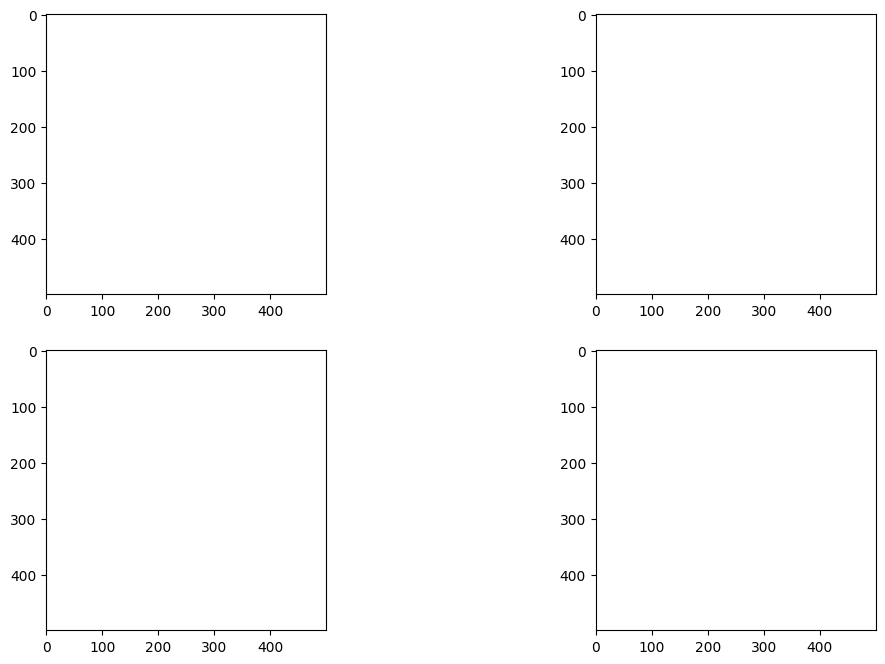

In [ ]:
display_images(rows_with_white_image,2,2,axis=True)

#### Images triées par densité (nombre de pixels non blancs)

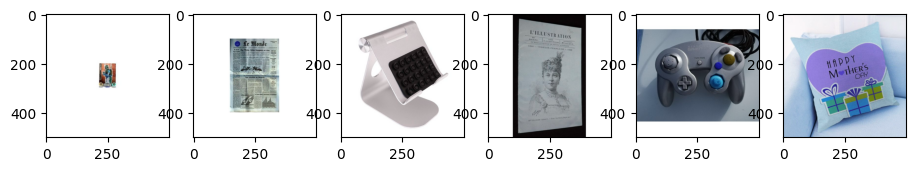

In [ ]:
# De densité faible à haute
rows = []
for a in np.linspace(0.01,1,6):
    rows.append(df[(df.essential_pixel_count < df.essential_pixel_count.quantile(a)) & (df.essential_pixel_count >= df.essential_pixel_count.quantile(a-.01))].sample(1))
rows = pd.concat(rows)
display_images(rows,1,7,axis=True)

#### Images selon rectangularité

Mesure à quel point le produit ressemble à un rectangle plein, en supposant que "blanc"="vide" (niveau de gris 254 ou 255).

In [ ]:
# Images à rectangularité faible mais non toutes blanches
rows = df[(df.rectangleness < .06) & (df.rectangleness > 0)]
rows.shape

(11, 17)

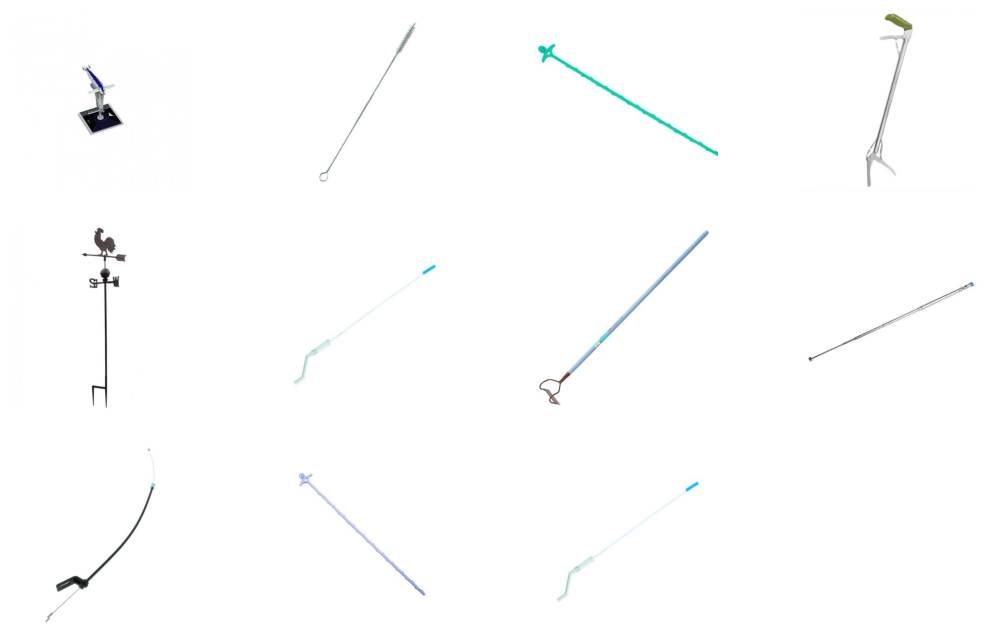

In [ ]:
display_images(rows,3,4)

In [ ]:
# Images à rectangularité moyenne
a=.40
rows = df[(df.rectangleness < a) & (df.rectangleness > a-.01)]
rows.shape

(483, 17)

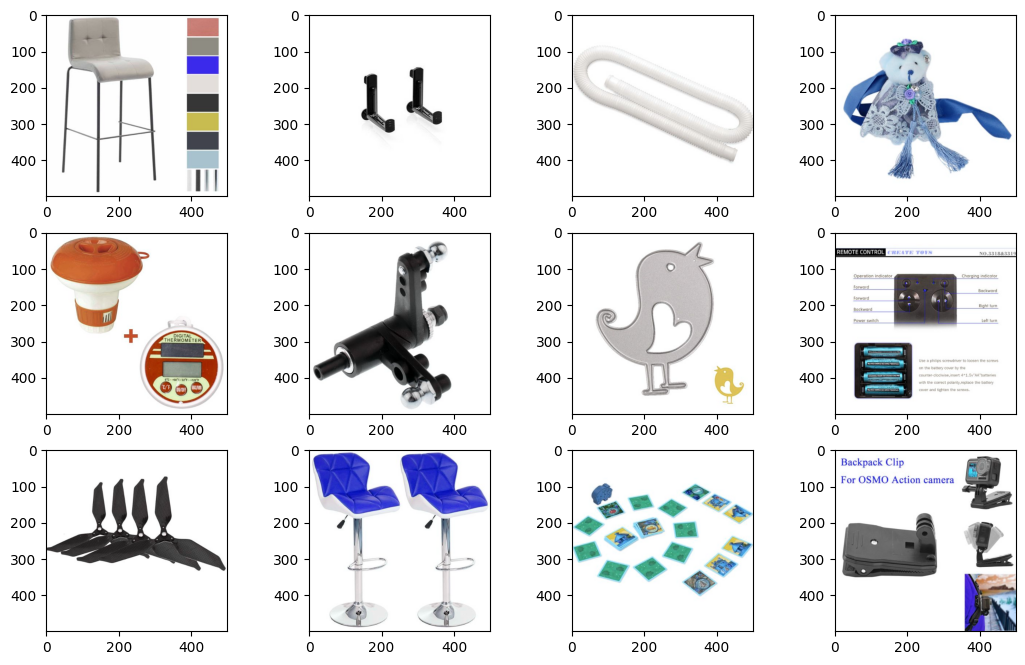

In [ ]:
display_images(rows[:12],3,4,axis=True)

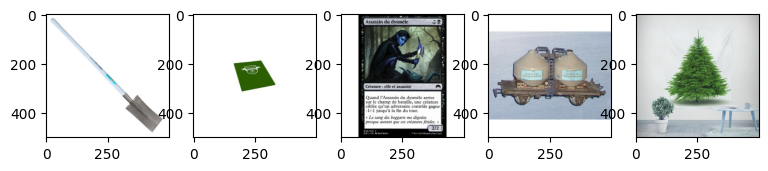

In [ ]:
# De rectangularité faible à haute (à quel point le produit ressemble à un rectangle plein, en supposant que "blanc"="vide")
rows = []
for a in np.linspace(0.01,1,5):
    rows.append(df[(df.rectangleness < df.rectangleness.quantile(a)) & (df.rectangleness >= df.rectangleness.quantile(a-.01))].sample(1))
rows = pd.concat(rows)
display_images(rows,1,7,axis=True)

#### Color features

In [ ]:
def get_image_color_stats(row, folder = '../../Dataset/images/image_train') -> dict:
    """
    Charge une image une seule fois et calcule rapidement les statistiques
    de couleur (moyenne, écart-type) et de niveaux de gris.

    Args:
        image_path (str): Le chemin vers le fichier image.

    Returns:
        dict: Un dictionnaire contenant les features calculées.
    """
    # 1. Charger l'image en couleur (BGR par défaut avec OpenCV)
    img_color = load_image(row, color=True, folder = folder)

    # Gérer le cas où l'image n'a pas pu être chargée
    if img_color is None:
        # Renvoyer un dictionnaire avec des zéros pour maintenir la structure des données
        keys = ['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b',
                'mean_gray', 'std_gray']
        return {key: 0 for key in keys}

    # 2. Calculer les stats pour les canaux de couleur
    # OpenCV charge en BGR, donc l'ordre est Bleu, Vert, Rouge
    mean_b, mean_g, mean_r = np.mean(img_color, axis=(0, 1))
    std_b, std_g, std_r = np.std(img_color, axis=(0, 1))

    # 3. Convertir en niveaux de gris (opération en mémoire, très rapide)
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # 4. Calculer les stats pour les niveaux de gris
    mean_gray = np.mean(img_gray)
    std_gray = np.std(img_gray)

    return {
        'mean_r': mean_r,
        'mean_g': mean_g,
        'mean_b': mean_b,
        'std_r': std_r,
        'std_g': std_g,
        'std_b': std_b,
        'mean_gray': mean_gray,
        'std_gray': std_gray
    }

In [ ]:
df.sample(3).apply(get_image_color_stats,axis=1)

59489    {'mean_r': 211.963352, 'mean_g': 208.227424, '...
52863    {'mean_r': 234.085052, 'mean_g': 230.717328, '...
36752    {'mean_r': 203.321756, 'mean_g': 197.278996, '...
dtype: object

In [ ]:
# # Dure 2m47

# from joblib import Parallel, delayed

# print("Démarrage de l'extraction de features en parallèle...")
# # n_jobs=-1 utilise tous les coeurs disponibles
# # backend="loky" est plus robuste pour les processus complexes
# results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
#     delayed(get_image_color_stats)(row) for row in df.itertuples(index=False)
# )
# print("Extraction terminée.")

[Parallel(n_jobs=-1)]: Done 29856 tasks      | elapsed:   57.0s
[Parallel(n_jobs=-1)]: Done 30568 tasks      | elapsed:   58.5s
[Parallel(n_jobs=-1)]: Done 31280 tasks      | elapsed:   59.9s
[Parallel(n_jobs=-1)]: Done 32008 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 32736 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 33480 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 34224 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 34984 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 35744 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 36520 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 37296 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 38088 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 38880 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 39688 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 40496 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 41320 tasks 

Extraction terminée.


[Parallel(n_jobs=-1)]: Done 84865 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 84916 out of 84916 | elapsed:  2.8min finished


In [ ]:
# results[:5]

[{'mean_r': np.float64(251.474248),
  'mean_g': np.float64(246.770248),
  'mean_b': np.float64(246.584628),
  'std_r': np.float64(17.51975527330876),
  'std_g': np.float64(31.300441626506935),
  'std_b': np.float64(30.723063748544647),
  'mean_gray': np.float64(248.156512),
  'std_gray': np.float64(26.766075692821616)},
 {'mean_r': np.float64(233.709468),
  'mean_g': np.float64(232.69754),
  'mean_b': np.float64(231.393308),
  'std_r': np.float64(55.31081343775671),
  'std_g': np.float64(57.0814085492505),
  'std_b': np.float64(58.89507593004622),
  'mean_gray': np.float64(232.853372),
  'std_gray': np.float64(56.726423404173964)},
 {'mean_r': np.float64(249.347872),
  'mean_g': np.float64(251.50132),
  'mean_b': np.float64(253.407576),
  'std_r': np.float64(23.90161519802634),
  'std_g': np.float64(15.248646833648603),
  'std_b': np.float64(7.303718080832729),
  'mean_gray': np.float64(251.07694),
  'std_gray': np.float64(16.857683477761707)},
 {'mean_r': np.float64(169.912284),
  'me

In [ ]:
# len(results)

84916

In [ ]:
# # Convertir la liste de résultats (dictionnaires) en un DataFrame
# image_features_df = pd.DataFrame(results, index=df.index)

In [ ]:
# image_features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mean_r     84916 non-null  float64
 1   mean_g     84916 non-null  float64
 2   mean_b     84916 non-null  float64
 3   std_r      84916 non-null  float64
 4   std_g      84916 non-null  float64
 5   std_b      84916 non-null  float64
 6   mean_gray  84916 non-null  float64
 7   std_gray   84916 non-null  float64
dtypes: float64(8)
memory usage: 7.8 MB


In [ ]:
# image_features_df.iloc[:5]

,mean_r,mean_g,mean_b,std_r,std_g,std_b,mean_gray,std_gray
0,251.474248,246.770248,246.584628,17.519755,31.300442,30.723064,248.156512,26.766076
1,233.709468,232.697540,231.393308,55.310813,57.081409,58.895076,232.853372,56.726423
2,249.347872,251.501320,253.407576,23.901615,15.248647,7.303718,251.076940,16.857683
3,169.912284,152.230752,149.071656,90.097713,105.119124,107.814486,157.154192,100.303695
4,225.420976,234.073496,238.190560,69.810629,48.107267,40.819651,231.958232,52.490279


In [ ]:
# df = df.join(image_features_df)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   designation            84916 non-null  object 
 1   description            55116 non-null  object 
 2   productid              84916 non-null  int64  
 3   imageid                84916 non-null  int64  
 4   prdtypecode            84916 non-null  int64  
 5   len_designation        84916 non-null  int64  
 6   len_description        84916 non-null  int64  
 7   essential_width        84916 non-null  int64  
 8   essential_height       84916 non-null  int64  
 9   aspect_ratio           84916 non-null  float64
 10  essential_area         84916 non-null  int64  
 11  essential_pixel_count  84916 non-null  int64  
 12  x_min                  84916 non-null  int64  
 13  y_min                  84916 non-null  int64  
 14  x_max                  84916 non-null  int64  
 15  y_max  

In [ ]:
# mean_[rgb] : teinte globale de l'image
# mean_gray : luminosité de l'image
# std_[rgb] : contraste, variété des couleurs
# std_gray : variété de la luminosité
df.loc[:,'mean_r':].describe()

,mean_r,mean_g,mean_b,std_r,std_g,std_b,mean_gray,std_gray
count,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000
mean,199.838750,195.519166,191.964443,61.508723,63.587782,66.137707,196.406031,62.060626
std,40.888817,41.798584,44.358478,24.263654,22.944080,23.814731,40.954589,22.138018
min,1.701404,0.938964,1.689608,0.000000,0.000000,0.000000,2.440544,0.000000
25%,174.469133,168.015495,162.310952,43.405259,46.872417,48.592731,169.294558,46.012848
50%,208.281432,203.418850,200.491772,62.775438,65.205241,68.744376,204.139580,63.441236
75%,232.894265,229.547917,228.709854,79.872333,80.888554,84.621927,229.664644,78.658299
max,255.000000,255.000000,255.000000,126.253580,126.253580,126.253580,255.000000,126.253580


## Save df

In [ ]:
print(df.columns.tolist())

['designation', 'description', 'productid', 'imageid', 'prdtypecode', 'len_designation', 'len_description', 'essential_width', 'essential_height', 'aspect_ratio', 'essential_area', 'essential_pixel_count', 'x_min', 'y_min', 'x_max', 'y_max', 'rectangleness', 'mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b', 'mean_gray', 'std_gray']


In [85]:
base_cols=['designation', 'description', 'productid', 'imageid', 'prdtypecode', 'essential_pixel_count', 'x_min', 'y_min', 'x_max', 'y_max', 'mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b', 'mean_gray', 'std_gray']

In [ ]:
# base_df = df[base_cols]

In [ ]:
# base_df.to_parquet('../../Dataset2/df.parquet', compression='gzip')

## Load df

In [99]:
import pandas as pd
def load_extended_df(path='../../Dataset2/df.parquet'):
    df = pd.read_parquet(path)

    # Longueurs des textes.
    df['len_designation']=df.designation.apply(len)
    df['len_description']=df.description.fillna('').apply(len)

    # Taille de la partie non blanche.
    df['essential_width'] = df.x_max - df.x_min + 1
    df['essential_height'] = df.y_max - df.y_min + 1
    df['essential_aspect_ratio'] = df.essential_width / df.essential_height

    # Aire de la partie non blanche.
    df['essential_area'] = df.essential_width * df.essential_height

    # Mesure à quel point la partie non blanche ressemble à un rectangle plein.
    df['rectangleness'] = df.essential_pixel_count / df.essential_area

    return df

df=load_extended_df(path='../../Dataset2/df.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   designation             84916 non-null  object 
 1   description             55116 non-null  object 
 2   productid               84916 non-null  int64  
 3   imageid                 84916 non-null  int64  
 4   prdtypecode             84916 non-null  int64  
 5   x_min                   84916 non-null  int64  
 6   y_min                   84916 non-null  int64  
 7   x_max                   84916 non-null  int64  
 8   y_max                   84916 non-null  int64  
 9   mean_r                  84916 non-null  float64
 10  mean_g                  84916 non-null  float64
 11  mean_b                  84916 non-null  float64
 12  std_r                   84916 non-null  float64
 13  std_g                   84916 non-null  float64
 14  std_b                   84916 non-null  flo